In [2]:
import os
print("Current working directory:")
print(os.getcwd())

Current working directory:
d:\School\UCLA\0 PIC 16B\Code\nfl-model\notebooks


In [5]:
import pandas as pd
import os

DATA_PATH = "../data/processed"

qb = pd.read_csv(os.path.join(DATA_PATH, "qb_modeling_data.csv"))
skill = pd.read_csv(os.path.join(DATA_PATH, "skill_modeling_data.csv"))
ol = pd.read_csv(os.path.join(DATA_PATH, "ol_modeling_data.csv"))
front7 = pd.read_csv(os.path.join(DATA_PATH, "front7_modeling_data.csv"))
db = pd.read_csv(os.path.join(DATA_PATH, "db_modeling_data.csv"))

datasets = {
    "QB": qb,
    "Skill": skill,
    "OL": ol,
    "Front7": front7,
    "DB": db
}

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [6]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Missing dr_av:", df["dr_av"].isna().sum())
    print("dr_av summary:")
    print(df["dr_av"].describe())


QB
Shape: (84, 50)
Missing dr_av: 0
dr_av summary:
count     84.000000
mean      24.714286
std       33.471287
min       -4.000000
25%        1.000000
50%        7.500000
75%       42.250000
max      125.000000
Name: dr_av, dtype: float64

Skill
Shape: (548, 50)
Missing dr_av: 0
dr_av summary:
count    548.00000
mean      12.04562
std       15.80953
min        0.00000
25%        1.00000
50%        6.00000
75%       17.00000
max       97.00000
Name: dr_av, dtype: float64

OL
Shape: (229, 50)
Missing dr_av: 0
dr_av summary:
count    229.000000
mean      19.401747
std       19.628685
min        0.000000
25%        5.000000
50%       13.000000
75%       28.000000
max      103.000000
Name: dr_av, dtype: float64

Front7
Shape: (627, 50)
Missing dr_av: 0
dr_av summary:
count    627.000000
mean      15.320574
std       19.528326
min        0.000000
25%        3.000000
50%        9.000000
75%       20.000000
max      123.000000
Name: dr_av, dtype: float64

DB
Shape: (407, 50)
Missing dr_av: 0


In [8]:
for name, df in datasets.items():
    print(f"\n{name} — Missing Values Summary")
    
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    
    if len(missing) == 0:
        print("No missing values.")
    else:
        print(missing.head(20))


QB — Missing Values Summary
rb_rec_Y/R     84
rb_rush_TD     84
rb_rec_Rec     84
rb_rush_Y/A    84
rb_rush_Yds    84
rb_rush_Att    84
rb_rush_Y/G    84
Sk             84
rec_TD         84
rec_Y/R        84
rec_Yds        84
rec_Rec        84
rec_Y/G        84
rb_rec_Y/G     84
rb_rec_TD      84
Solo           84
Ast            84
Comb           84
TFL            84
Sk/G           84
dtype: int64

Skill — Missing Values Summary
Rate       548
qb_Cmp     548
qb_Att     548
qb_Inc     548
qb_Cmp%    548
qb_Yds     548
qb_TD      548
qb_Int     548
qb_TD%     548
qb_Int%    548
qb_Y/A     548
qb_AY/A    548
qb_Y/C     548
qb_Y/G     548
Ast        548
Comb       548
TFL        548
Sk/G       548
Int        548
IntTD      548
dtype: int64

OL — Missing Values Summary
Rate           229
qb_Cmp         229
qb_Inc         229
qb_Att         229
qb_Cmp%        229
qb_Yds         229
rb_rec_TD      229
qb_TD          229
qb_Int         229
qb_TD%         229
qb_Int%        229
qb_Y/A         

In [9]:
for name, df in datasets.items():
    print(f"\n{name} — % Missing (Top 10)")
    
    pct_missing = (df.isna().mean() * 100)
    pct_missing = pct_missing[pct_missing > 0].sort_values(ascending=False)
    
    print(pct_missing.head(10))


QB — % Missing (Top 10)
rb_rec_Y/R     100.0
rb_rush_TD     100.0
rb_rec_Rec     100.0
rb_rush_Y/A    100.0
rb_rush_Yds    100.0
rb_rush_Att    100.0
rb_rush_Y/G    100.0
Sk             100.0
rec_TD         100.0
rec_Y/R        100.0
dtype: float64

Skill — % Missing (Top 10)
Rate       100.0
qb_Cmp     100.0
qb_Att     100.0
qb_Inc     100.0
qb_Cmp%    100.0
qb_Yds     100.0
qb_TD      100.0
qb_Int     100.0
qb_TD%     100.0
qb_Int%    100.0
dtype: float64

OL — % Missing (Top 10)
Rate         100.0
qb_Cmp       100.0
qb_Inc       100.0
qb_Att       100.0
qb_Cmp%      100.0
qb_Yds       100.0
rb_rec_TD    100.0
qb_TD        100.0
qb_Int       100.0
qb_TD%       100.0
dtype: float64

Front7 — % Missing (Top 10)
Rate       100.0
qb_Cmp     100.0
qb_Att     100.0
qb_Inc     100.0
qb_Yds     100.0
qb_Cmp%    100.0
qb_TD      100.0
qb_Int     100.0
qb_AY/A    100.0
qb_TD%     100.0
dtype: float64

DB — % Missing (Top 10)
Rate          100.0
qb_Cmp        100.0
qb_Att        100.0
rb_rush_

In [10]:
for name, df in datasets.items():
    print(f"\n{name} — Constant Columns")
    
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    
    if constant_cols:
        print(constant_cols)
    else:
        print("No constant columns.")


QB — Constant Columns
['Pos', 'rb_rush_Y/G', 'rb_rush_Att', 'rb_rush_Yds', 'rb_rush_Y/A', 'rb_rush_TD', 'rb_rec_Rec', 'rb_rec_Y/R', 'rb_rec_TD', 'rb_rec_Y/G', 'rec_Y/G', 'rec_Rec', 'rec_Yds', 'rec_Y/R', 'rec_TD', 'Sk', 'Solo', 'Ast', 'Comb', 'TFL', 'Sk/G', 'Int', 'IntTD', 'PD', 'PosGroup']

Skill — Constant Columns
['Rate', 'qb_Cmp', 'qb_Att', 'qb_Inc', 'qb_Cmp%', 'qb_Yds', 'qb_TD', 'qb_Int', 'qb_TD%', 'qb_Int%', 'qb_Y/A', 'qb_AY/A', 'qb_Y/C', 'qb_Y/G', 'Sk', 'Solo', 'Ast', 'Comb', 'TFL', 'Sk/G', 'Int', 'IntTD', 'PD', 'PosGroup']

OL — Constant Columns
['Rate', 'qb_Cmp', 'qb_Att', 'qb_Inc', 'qb_Cmp%', 'qb_Yds', 'qb_TD', 'qb_Int', 'qb_TD%', 'qb_Int%', 'qb_Y/A', 'qb_AY/A', 'qb_Y/C', 'qb_Y/G', 'rb_rush_Y/G', 'rb_rush_Att', 'rb_rush_Yds', 'rb_rush_Y/A', 'rb_rush_TD', 'rb_rec_Rec', 'rb_rec_Y/R', 'rb_rec_TD', 'rb_rec_Y/G', 'rec_Y/G', 'rec_Rec', 'rec_Yds', 'rec_Y/R', 'rec_TD', 'Sk', 'Solo', 'Ast', 'Comb', 'TFL', 'Sk/G', 'Int', 'IntTD', 'PD', 'PosGroup']

Front7 — Constant Columns
['Rate', 'q

In [11]:
for name, df in datasets.items():
    print(f"\n{name} — Duplicate Rows:", df.duplicated().sum())


QB — Duplicate Rows: 0

Skill — Duplicate Rows: 0

OL — Duplicate Rows: 0

Front7 — Duplicate Rows: 0

DB — Duplicate Rows: 0


In [12]:
for name, df in datasets.items():
    print(f"\n{name} — Top Correlations with dr_av")
    
    numeric_df = df.select_dtypes(include=np.number)
    corr = numeric_df.corr()["dr_av"].sort_values(ascending=False)
    
    print(corr.head(10))
    print(corr.tail(5))


QB — Top Correlations with dr_av
dr_av      1.000000
qb_TD%     0.383110
Rate       0.294242
qb_AY/A    0.284687
qb_TD      0.269426
qb_Y/A     0.224769
qb_Cmp%    0.138287
qb_Yds     0.132267
qb_Y/C     0.127768
qb_Y/G     0.119282
Name: dr_av, dtype: float64
TFL     NaN
Sk/G    NaN
Int     NaN
IntTD   NaN
PD      NaN
Name: dr_av, dtype: float64

Skill — Top Correlations with dr_av
dr_av          1.000000
rb_rush_Y/G    0.352989
rb_rush_Yds    0.301457
rec_Y/G        0.293917
rb_rush_TD     0.289227
rb_rush_Y/A    0.250484
rb_rush_Att    0.235192
rb_rec_Y/G     0.234465
rec_TD         0.210633
rec_Yds        0.204582
Name: dr_av, dtype: float64
TFL     NaN
Sk/G    NaN
Int     NaN
IntTD   NaN
PD      NaN
Name: dr_av, dtype: float64

OL — Top Correlations with dr_av
dr_av         1.000000
G             0.122915
To           -0.141726
Draft Year   -0.145231
From         -0.155285
Round        -0.501456
Pick         -0.504991
Rate               NaN
qb_Cmp             NaN
qb_Att          

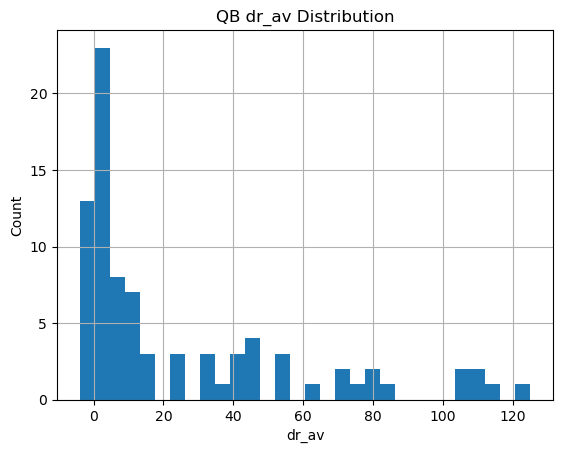

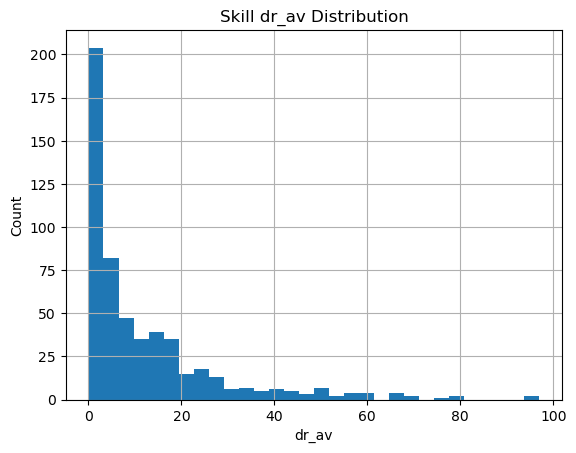

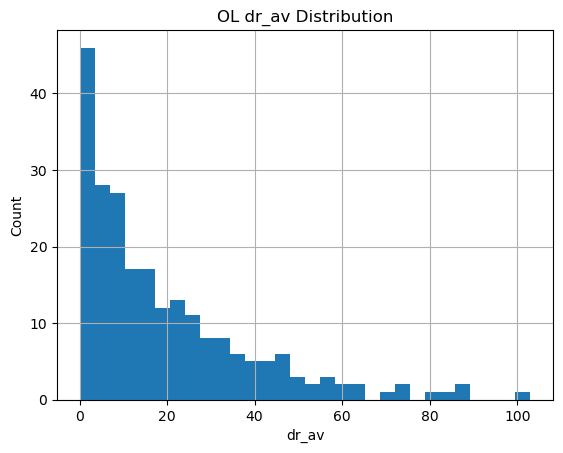

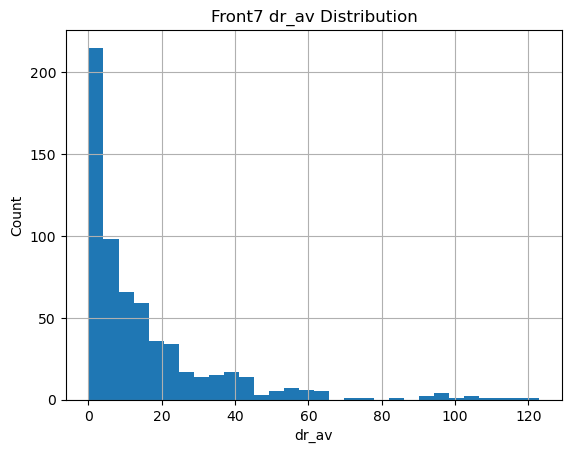

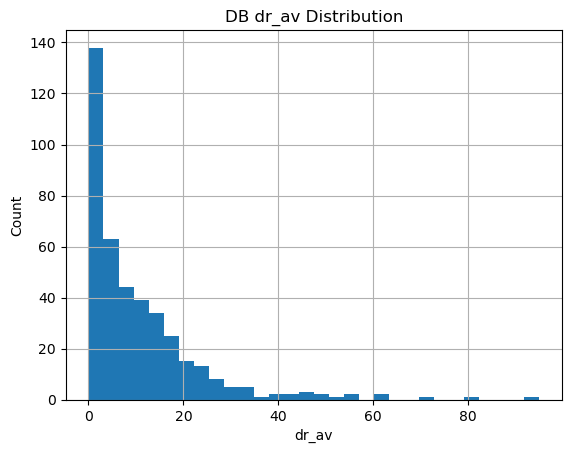

In [13]:
import matplotlib.pyplot as plt

for name, df in datasets.items():
    plt.figure()
    df["dr_av"].hist(bins=30)
    plt.title(f"{name} dr_av Distribution")
    plt.xlabel("dr_av")
    plt.ylabel("Count")
    plt.show()

In [14]:
def drop_empty_columns(df):
    return df.dropna(axis=1, how='all')

qb = drop_empty_columns(qb)
skill = drop_empty_columns(skill)
ol = drop_empty_columns(ol)
front7 = drop_empty_columns(front7)
db = drop_empty_columns(db)

In [16]:
qb.columns, skill.columns, ol.columns, front7.columns, db.columns

(Index(['Player', 'Rate', 'Draft Team', 'Round', 'Pick', 'Draft Year',
        'Draft College', 'From', 'To', 'G', 'qb_Cmp', 'qb_Att', 'qb_Inc',
        'qb_Cmp%', 'qb_Yds', 'qb_TD', 'qb_Int', 'qb_TD%', 'qb_Int%', 'qb_Y/A',
        'qb_AY/A', 'qb_Y/C', 'qb_Y/G', 'Pos', 'Team', 'dr_av', 'PosGroup'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'rb_rush_Y/G', 'rb_rush_Att',
        'rb_rush_Yds', 'rb_rush_Y/A', 'rb_rush_TD', 'rb_rec_Rec', 'rb_rec_Y/R',
        'rb_rec_TD', 'rb_rec_Y/G', 'rec_Y/G', 'rec_Rec', 'rec_Yds', 'rec_Y/R',
        'rec_TD', 'dr_av', 'PosGroup'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'dr_av', 'PosGroup'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'Sk', 'Solo', 'Ast',

In [17]:
def drop_constant_columns(df):
    return df.loc[:, df.nunique() > 1]

qb = drop_constant_columns(qb)
skill = drop_constant_columns(skill)
ol = drop_constant_columns(ol)
front7 = drop_constant_columns(front7)
db = drop_constant_columns(db)

In [19]:
qb.columns, skill.columns, ol.columns, front7.columns, db.columns

(Index(['Player', 'Rate', 'Draft Team', 'Round', 'Pick', 'Draft Year',
        'Draft College', 'From', 'To', 'G', 'qb_Cmp', 'qb_Att', 'qb_Inc',
        'qb_Cmp%', 'qb_Yds', 'qb_TD', 'qb_Int', 'qb_TD%', 'qb_Int%', 'qb_Y/A',
        'qb_AY/A', 'qb_Y/C', 'qb_Y/G', 'Team', 'dr_av'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'rb_rush_Y/G', 'rb_rush_Att',
        'rb_rush_Yds', 'rb_rush_Y/A', 'rb_rush_TD', 'rb_rec_Rec', 'rb_rec_Y/R',
        'rb_rec_TD', 'rb_rec_Y/G', 'rec_Y/G', 'rec_Rec', 'rec_Yds', 'rec_Y/R',
        'rec_TD', 'dr_av'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'dr_av'],
       dtype='str'),
 Index(['Player', 'Draft Team', 'Round', 'Pick', 'Draft Year', 'Draft College',
        'From', 'To', 'G', 'Pos', 'Team', 'Sk', 'Solo', 'Ast', 'Comb', 'TFL',
        'Sk/G', 'dr_av'],
 

In [18]:
for name, df in datasets.items():
    print(name, df.shape)

QB (84, 50)
Skill (548, 50)
OL (229, 50)
Front7 (627, 50)
DB (407, 50)


In [ ]:
import numpy as np

def prepare_xy(df, drop_draft_slot=False):
    
    drop_cols = [
        "Player", 
        "Draft Team", 
        "Draft College",
        "Team",
        "Pos"
    ]
    
    df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    # Target
    y = df_clean["dr_av"]
    
    # Features
    X = df_clean.drop(columns=["dr_av"])
    
    # Drop pick
    if drop_draft_slot:
        for col in ["Round", "Pick"]:
            if col in X.columns:
                X = X.drop(columns=[col])
    
    # Keep numeric only
    X = X.select_dtypes(include=np.number)
    
    return X, y

In [ ]:
datasets_clean = {
    "QB": qb,
    "Skill": skill,
    "OL": ol,
    "Front7": front7,
    "DB": db
}

prepared_data = {}

for name, df in datasets_clean.items():
    X, y = prepare_xy(df, drop_draft_slot=False)
    prepared_data[name] = (X, y)
    
    print(f"{name}")
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print()

QB
X shape: (84, 20)
y shape: (84,)

Skill
X shape: (548, 20)
y shape: (548,)

OL
X shape: (229, 6)
y shape: (229,)

Front7
X shape: (627, 12)
y shape: (627,)

DB
X shape: (407, 9)
y shape: (407,)



In [23]:
for name, (X, y) in prepared_data.items():
    print(name, "Total NaNs in X:", X.isna().sum().sum())

QB Total NaNs in X: 7
Skill Total NaNs in X: 4200
OL Total NaNs in X: 6
Front7 Total NaNs in X: 0
DB Total NaNs in X: 0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

results = {}

for name, (X, y) in prepared_data.items():
    
    if X.shape[1] == 0:
        print(f"{name} has no usable features.")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    if name == "Skill":
        imputer = SimpleImputer(strategy="constant", fill_value=0)
    else:
        imputer = SimpleImputer(strategy="median")
    
    model = Pipeline([
        ("imputer", imputer),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = (rmse, r2)
    
    print(f"{name}")
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

QB
RMSE: 45.395947911898645
R²: -0.43651810235346233

Skill
RMSE: 14.095526343809325
R²: 0.12587396570755494

OL
RMSE: 15.820432774041125
R²: 0.0014096778518608577

Front7
RMSE: 15.516113960097162
R²: 0.3439042197108455

DB
RMSE: 17.173145176750115
R²: 0.044411802413708346



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np

log_results = {}

for name, (X, y) in prepared_data.items():
    
    if X.shape[1] == 0:
        print(f"{name} has no usable features.")
        continue
    
    # Fix negative QB AV before log
    y_adj = y.copy()
    if y_adj.min() < 0:
        shift = abs(y_adj.min())
        y_adj = y_adj + shift
    else:
        shift = 0
    
    y_log = np.log1p(y_adj)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )
    
    if name == "Skill":
        imputer = SimpleImputer(strategy="constant", fill_value=0)
    else:
        imputer = SimpleImputer(strategy="median")
    
    model = Pipeline([
        ("imputer", imputer),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    
    # log scale
    r2_log = r2_score(y_test, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
    
    # original scale
    y_pred_original = np.expm1(y_pred_log) - shift
    y_test_original = np.expm1(y_test) - shift
    
    rmse_original = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    
    log_results[name] = (rmse_original, r2_log)
    
    print(f"{name}")
    print("RMSE (original scale):", rmse_original)
    print("R² (log scale):", r2_log)
    print()

QB
RMSE (original scale): 48.22497237503496
R² (log scale): -0.17436907715131578

Skill
RMSE (original scale): 13.908606393579431
R² (log scale): 0.22052021305442193

OL
RMSE (original scale): 15.661560803141537
R² (log scale): -0.04463600201349438

Front7
RMSE (original scale): 16.71438934375175
R² (log scale): 0.4476036936008031

DB
RMSE (original scale): 18.13111272048174
R² (log scale): 0.08545685286611793



In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor


# =========================
# Model Dictionary
# =========================

model_dict = {
    "Dummy": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ),
    "HistGB": HistGradientBoostingRegressor(
        max_depth=None,
        learning_rate=0.1,
        max_iter=200,
        random_state=42
    )
}


# =========================
# Run All Models
# =========================

results = []

for position_name, (X, y) in prepared_data.items():
    
    if X.shape[1] == 0:
        continue
    
    # fix negative QB AV before log
    y_adj = y.copy()
    if y_adj.min() < 0:
        shift = abs(y_adj.min())
        y_adj = y_adj + shift
    else:
        shift = 0
    
    y_log = np.log1p(y_adj)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )
    
    if position_name == "Skill":
        imputer = SimpleImputer(strategy="constant", fill_value=0)
    else:
        imputer = SimpleImputer(strategy="median")
    
    for model_name, model in model_dict.items():
        
        pipeline = Pipeline([
            ("imputer", imputer),
            ("model", model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred_log = pipeline.predict(X_test)
        
        # Log-scale R²
        r2_log = r2_score(y_test, y_pred_log)
        
        # RMSE on original scale
        y_pred_original = np.expm1(y_pred_log) - shift
        y_test_original = np.expm1(y_test) - shift
        
        rmse_original = np.sqrt(
            mean_squared_error(y_test_original, y_pred_original)
        )
        
        results.append({
            "Position": position_name,
            "Model": model_name,
            "R2_log": r2_log,
            "RMSE_original": rmse_original
        })


# =========================
# Create Results Table
# =========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["Position", "R2_log"],
    ascending=[True, False]
)

results_df.reset_index(drop=True)

,Position,Model,R2_log,RMSE_original
0,DB,RandomForest,0.148702,17.633832
1,DB,Ridge,0.085650,18.130263
2,DB,Dummy,-0.063149,19.438327
3,DB,HistGB,-0.073888,18.310912
4,Front7,Ridge,0.447269,16.712851
5,Front7,RandomForest,0.317953,16.860059
6,Front7,HistGB,0.083050,17.232339
7,Front7,Dummy,-0.000115,20.895700
8,OL,Dummy,-0.020420,16.570709
9,OL,HistGB,-0.041110,17.292539
